In [ ]:
# Comment if using macos, otherwise run the following command to check if GPU is available.
# !nvidia-smi

In [2]:
# !git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

In [3]:
# cd /content/Locality-iN-Locality

In [4]:
pip install torchattacks

You should consider upgrading via the '/Users/hd-569/Documents/Locality-iN-Locality/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install matplotlib
%pip install torchsummary

You should consider upgrading via the '/Users/hd-569/Documents/Locality-iN-Locality/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/hd-569/Documents/Locality-iN-Locality/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [7]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.8.0
Torchvision 0.23.0
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [ ]:
# Comment if already downloaded the dataset, otherwise run the following commands to download and unzip the dataset.
# !mkdir data

# !curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
# !curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
# !curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

In [ ]:
# !unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
# !unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
# !unzip data/GTSRB_Final_Test_GT.zip -d data/

In [10]:
import shutil

In [11]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]
  

  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [12]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7) 
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]
                   

In [13]:
batch_size = 15

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([                   
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([                    
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

In [14]:
batch = next(iter(train_loader))
train_data = batch[0]

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)
        
        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

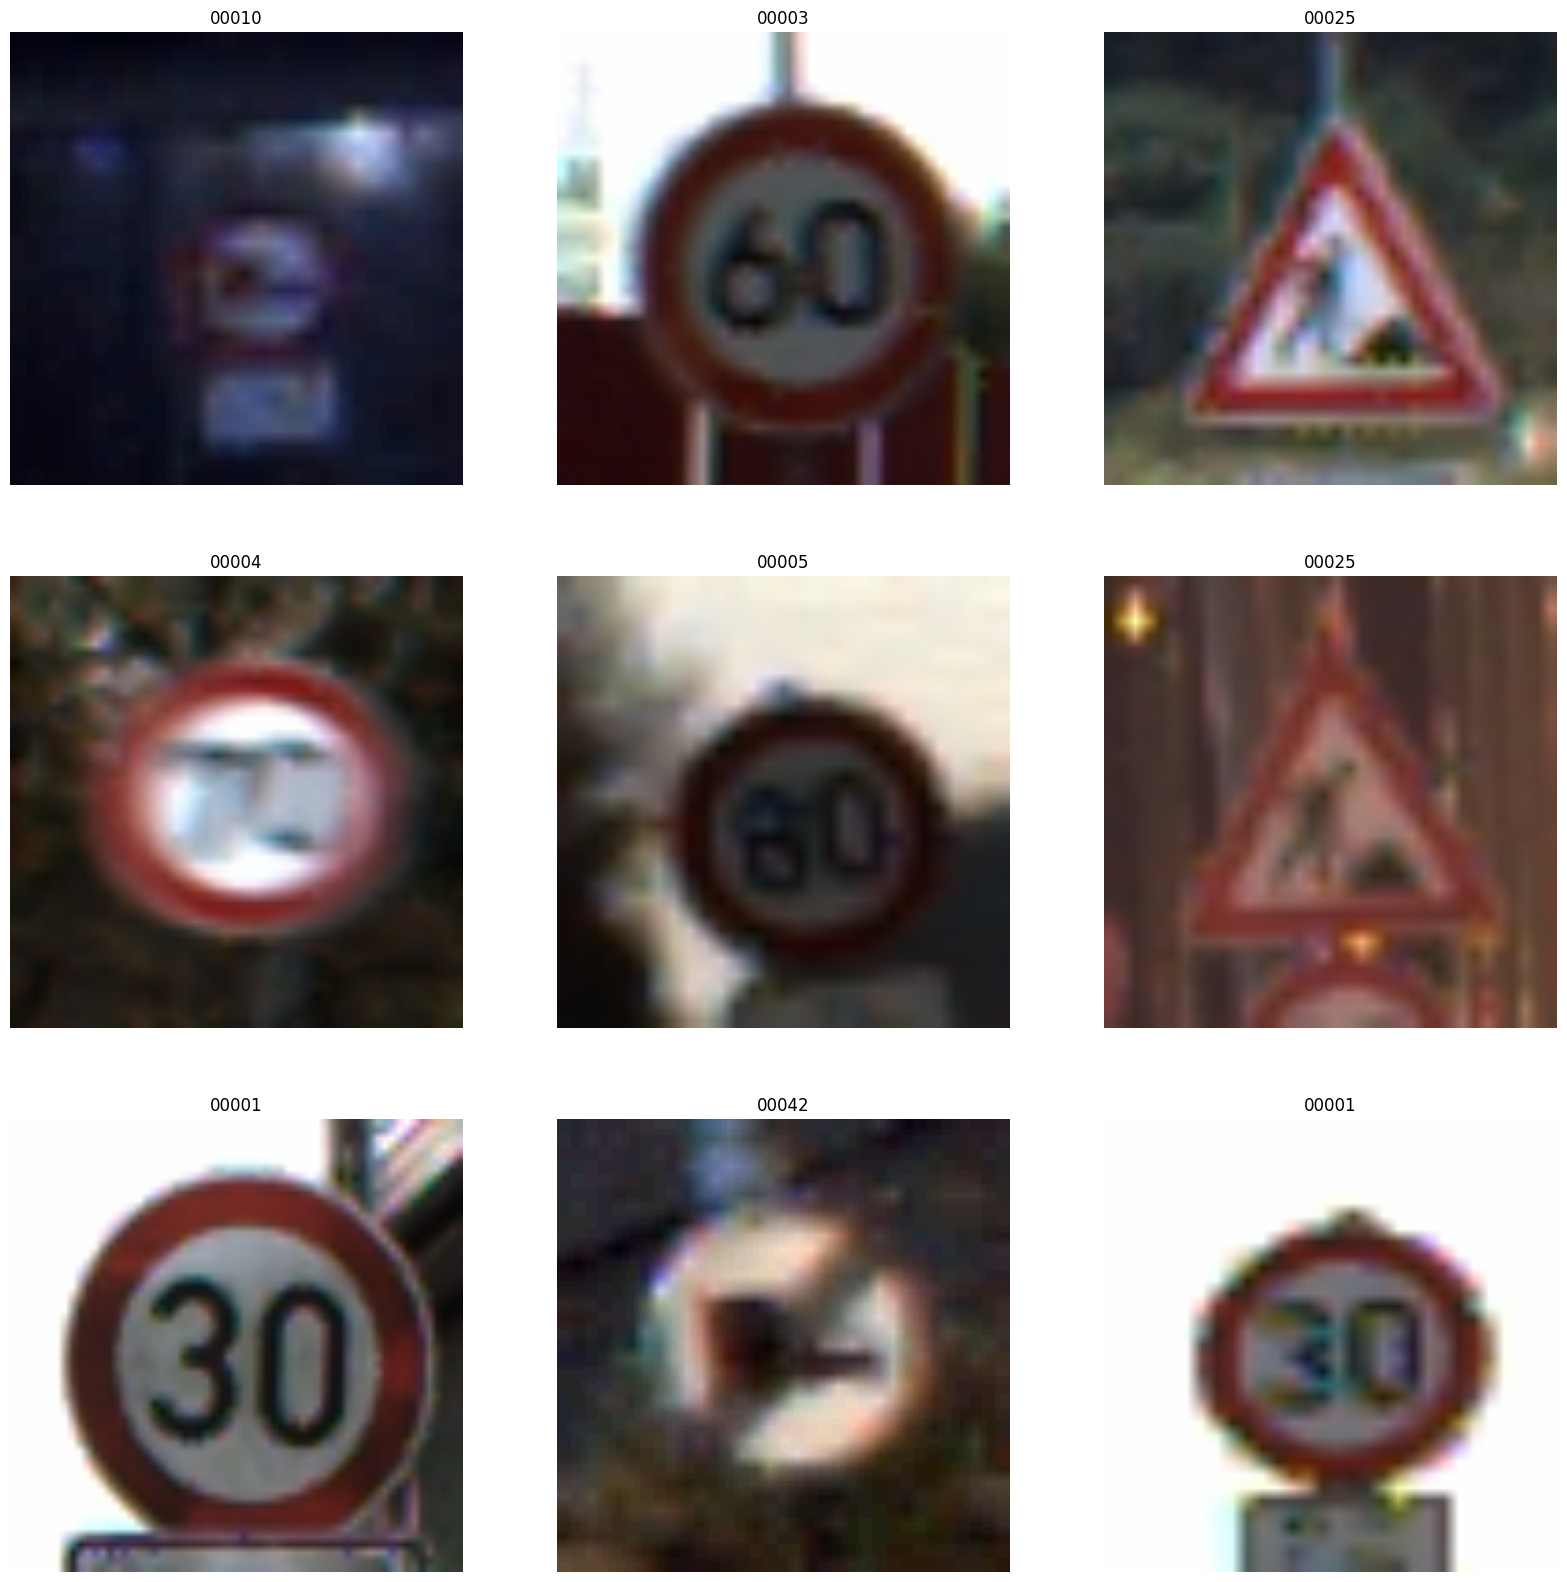

In [16]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [17]:
pip install timm

You should consider upgrading via the '/Users/hd-569/Documents/Locality-iN-Locality/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install einops

You should consider upgrading via the '/Users/hd-569/Documents/Locality-iN-Locality/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [19]:
from LNL import LNL_Ti as small

/Users/hd-569/Documents/Locality-iN-Locality/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/hd-569/Documents/Locality-iN-Locality/venv/lib/python3.9/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/hd-569/Documents/Locality-iN-Locality/venv/lib/python3.9/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/hd-569/Documents/Locality-iN-Locality/venv/lib/python3.9/site-packages/timm/models/registry.

In [20]:
model = small(pretrained=False)

In [21]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [22]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [23]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

model = model.to(device)


Device: mps


## Train Locality-iN-Locality

In [24]:
num_epochs = 5

In [25]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [26]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size
    
    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.to(device)
        Y = batch_labels.to(device)

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/2613], Loss: 2.526779
Epoch [1/5], lter [400/2613], Loss: 2.660960
Epoch [1/5], lter [600/2613], Loss: 1.787086
Epoch [1/5], lter [800/2613], Loss: 1.488988
Epoch [1/5], lter [1000/2613], Loss: 0.961348
Epoch [1/5], lter [1200/2613], Loss: 0.478703
Epoch [1/5], lter [1400/2613], Loss: 0.379955
Epoch [1/5], lter [1600/2613], Loss: 0.241995
Epoch [1/5], lter [1800/2613], Loss: 0.066053
Epoch [1/5], lter [2000/2613], Loss: 0.013583
Epoch [1/5], lter [2200/2613], Loss: 0.038204
Epoch [1/5], lter [2400/2613], Loss: 0.050199
Epoch [1/5], lter [2600/2613], Loss: 0.224741
Epoch [2/5], lter [200/2613], Loss: 0.027246
Epoch [2/5], lter [400/2613], Loss: 0.015044
Epoch [2/5], lter [600/2613], Loss: 0.013349
Epoch [2/5], lter [800/2613], Loss: 0.001499
Epoch [2/5], lter [1000/2613], Loss: 0.025387
Epoch [2/5], lter [1200/2613], Loss: 0.021506
Epoch [2/5], lter [1400/2613], Loss: 0.002419
Epoch [2/5], lter [1600/2613], Loss: 0.003885
Epoch [2/5], lter [1800/2613], Loss: 0.012

## Test

In [27]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:
    
    images = images.to(device)
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.to(device)).sum()
    
print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 97.78 %


## FGSM attack

In [28]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:
    
    images = atk(images, labels).to(device)
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.to(device)).sum()
    
print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 70.30 %


## PGD attack

In [29]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:
    
    images = atk(images, labels).to(device)
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.to(device)).sum()
    
print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 55.42 %


## train LNL-MoEx

In [30]:
from LNL_MoEx import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

/Users/hd-569/Documents/Locality-iN-Locality/models/tnt_moex.py:313: UserWarning: Overwriting tnt_t_patch16_224 in registry with models.tnt_moex.tnt_t_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def tnt_t_patch16_224(pretrained=False, **kwargs):
/Users/hd-569/Documents/Locality-iN-Locality/models/tnt_moex.py:324: UserWarning: Overwriting tnt_s_patch16_224 in registry with models.tnt_moex.tnt_s_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def tnt_s_patch16_224(pretrained=False, **kwargs):
/Users/hd-569/Documents/Locality-iN-Locality/models/tnt_moex.py:335: UserWarning: Overwriting tnt_b_patch16_224 in registry with models.tnt_moex.tnt_b_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def tnt_b_patch16_224(pretrained=False, **kwargs):


In [31]:
model = model.to(device)

In [32]:
import time
# time.clock_gettime()

In [33]:
num_epochs = 5
moex_lam = .9
moex_prob = .7

In [34]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [35]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size
    
    for i, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/2613], Loss: 3.337846
Epoch [1/5], lter [400/2613], Loss: 3.547147
Epoch [1/5], lter [600/2613], Loss: 2.762380
Epoch [1/5], lter [800/2613], Loss: 2.215114
Epoch [1/5], lter [1000/2613], Loss: 1.791196
Epoch [1/5], lter [1200/2613], Loss: 1.570490
Epoch [1/5], lter [1400/2613], Loss: 1.324272
Epoch [1/5], lter [1600/2613], Loss: 0.947370
Epoch [1/5], lter [1800/2613], Loss: 0.866964
Epoch [1/5], lter [2000/2613], Loss: 0.706263
Epoch [1/5], lter [2200/2613], Loss: 0.126785
Epoch [1/5], lter [2400/2613], Loss: 0.716337
Epoch [1/5], lter [2600/2613], Loss: 0.804345
Epoch [2/5], lter [200/2613], Loss: 0.612879
Epoch [2/5], lter [400/2613], Loss: 0.637544
Epoch [2/5], lter [600/2613], Loss: 0.682544
Epoch [2/5], lter [800/2613], Loss: 0.021770
Epoch [2/5], lter [1000/2613], Loss: 0.621828
Epoch [2/5], lter [1200/2613], Loss: 0.570623
Epoch [2/5], lter [1400/2613], Loss: 0.625579
Epoch [2/5], lter [1600/2613], Loss: 0.015669
Epoch [2/5], lter [1800/2613], Loss: 0.634

## Number of Parameters

In [36]:
pip install ptflops

You should consider upgrading via the '/Users/hd-569/Documents/Locality-iN-Locality/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [37]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

  Cloning https://github.com/sovrasov/flops-counter.pytorch.git to /private/var/folders/d6/m4_fc13x50g2qvjkpgdnb_mm0000gn/T/pip-req-build-tmh8t2bm
  Running command git clone -q https://github.com/sovrasov/flops-counter.pytorch.git /private/var/folders/d6/m4_fc13x50g2qvjkpgdnb_mm0000gn/T/pip-req-build-tmh8t2bm
  Resolved https://github.com/sovrasov/flops-counter.pytorch.git to commit d612c7547445841a325fd2a1ff2ab27583f01bae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for ptflops: filename=ptflops-0.7.6-py3-none-any.whl size=19501 sha256=1f6e8ee21ae060fe038d2e49860991e20c62e4741e2782bbd47cb685bfcfebc0
  Stored in directory: /private/var/folders/d6/m4_fc13x50g2qvjkpgdnb_mm0000gn/T/pip-ephem-wheel-cache-52c5evb1/wheels/7b/ce/b8/e99458a955b5121dd05587f72a4a713fbcb398cb6451119346
Successfully built ptflops
  Attempting uninstall: ptflops
    Found existing installation: ptflops 0.7.5
    Uninst

In [40]:
import torch
from ptflops import get_model_complexity_info

net = model
macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                         print_per_layer_stat=True, verbose=True)
print("{:<30}  {:<8}".format("Computational complexity: ", macs))
print("{:<30}  {:<8}".format("Number of parameters: ", params))


LocalViT_TNT(
  6.04 M, 99.371% Params, 1.24 GMac, 99.710% MACs, 
  (pixel_embed): PixelEmbed(
    1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 
    (proj): Conv2d(1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 3, 12, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    (unfold): Unfold(0, 0.000% Params, 0.0 Mac, 0.000% MACs, kernel_size=4, dilation=1, padding=0, stride=4)
  )
  (norm1_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (proj): Linear(37.06 k, 0.610% Params, 7.26 MMac, 0.582% MACs, in_features=192, out_features=192, bias=True)
  (norm2_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (pos_drop): Dropout(0, 0.000% Params, 0.0 Mac, 0.000% MACs, p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      499.16 k, 8.215% Params, 102.59 MMac, 8.223% MACs, 
      (norm_in): LayerNorm(24, 0.000% Params, 37.63 KMac, 0.003% MACs, (12,), eps=1e-